## Iterative Training of Second-Phase Structural Models

This notebook trains separate XGBoost regressors for `Grain_2`,
`a_2`, `b_2`, and `c_2` using datasets from iterations 3–6.

### Workflow

1. Independently split each dataset into training and test sets (80/20).
2. Select features using training data: 7 for Grain_2, 15 for a_2
   and b_2, and 10 for c_2.
3. Train regressors and evaluate R², MAE, and RMSE.
4. Save models, selected features, predictions, and performance metrics.

`Grain_2` is trained using log1p-transformed targets, with exported
predictions and metrics converted back to the original scale.
The lattice parameters are modeled directly on their original scales.

Each target section can run independently. Run all cells within a
section sequentially, including the export step, before switching targets.
Splits are row-based; no cross-validation is performed.

## Grain2

In [1]:
# ============================================================
# 1. Import packages
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
# ============================================================
# 2. Load data and randomly split each dataset
# ============================================================

DATA_FILES = {
    "Iteration_3": "data/compound_3_Structural_Grain2.csv",
    "Iteration_4": "data/compound_4_Structural_Grain2.csv",
    "Iteration_5": "data/compound_5_Structural_Grain2.csv",
    "Iteration_6": "data/compound_6_Structural_Grain2.csv"
}

TARGET_COL = "Grain_2"
COMPOUND_COL = "compound"

RANDOM_STATE = 2025
TEST_SIZE = 0.20


# Store data from all iterations
iteration_data = {}


for iteration_name, data_file in DATA_FILES.items():

    # Load data
    data = pd.read_csv(data_file)

    # Remove automatically generated index columns
    data = data.loc[
        :,
        ~data.columns.str.startswith("Unnamed")
    ].copy()

    # Features
    X = (
        data
        .drop(
            columns=[
                TARGET_COL,
                COMPOUND_COL
            ],
            errors="ignore"
        )
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )

    # Original Grain2 values
    y_original = (
        data[TARGET_COL]
        .astype(float)
    )

    # Check Grain2 values before log transformation
    if (y_original < 0).any():

        raise ValueError(
            f"{iteration_name} contains negative Grain2 values."
        )

    # Log transformation
    y_log = np.log1p(
        y_original
    )


    # Randomly split each dataset
    (
        X_train,
        X_test,
        y_train_log,
        y_test_log
    ) = train_test_split(
        X,
        y_log,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )


    # Store the current iteration data
    iteration_data[iteration_name] = {
        "data_file": data_file,
        "data": data,
        "X_train": X_train,
        "X_test": X_test,
        "y_train_log": y_train_log,
        "y_test_log": y_test_log
    }


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Dataset shape:", data.shape)
    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))

    print(
        "Training log target range:",
        round(y_train_log.min(), 4),
        "to",
        round(y_train_log.max(), 4)
    )

    print(
        "Test log target range:",
        round(y_test_log.min(), 4),
        "to",
        round(y_test_log.max(), 4)
    )


Iteration_3
Dataset shape: (38, 27)
Training samples: 30
Test samples: 8
Training log target range: 2.0919 to 4.6347
Test log target range: 2.5802 to 3.8459

Iteration_4
Dataset shape: (42, 27)
Training samples: 33
Test samples: 9
Training log target range: 1.9169 to 4.3334
Test log target range: 2.0919 to 4.6347

Iteration_5
Dataset shape: (51, 27)
Training samples: 40
Test samples: 11
Training log target range: 1.9169 to 4.6347
Test log target range: 2.7279 to 4.4092

Iteration_6
Dataset shape: (55, 27)
Training samples: 44
Test samples: 11
Training log target range: 1.1939 to 4.6347
Test log target range: 0.4055 to 4.4092


In [3]:
# ============================================================
# 3. Feature selection
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]

    y_train_log = iteration["y_train_log"]


    # Initial model for feature selection
    reg_selector = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1
    )

    reg_selector.fit(
        X_train,
        y_train_log
    )


    # Extract feature importance
    feature_importance = (
        reg_selector.feature_importances_
    )

    feature_names = (
        X_train.columns.to_numpy()
    )


    # Keep the top 7 features
    num_features_to_keep = min(
        7,
        X_train.shape[1]
    )

    top_idx = np.argsort(
        feature_importance
    )[::-1][:num_features_to_keep]

    selected_features = (
        feature_names[top_idx]
        .tolist()
    )


    # Select training and test features
    X_train_selected = (
        X_train[selected_features]
        .copy()
    )

    X_test_selected = (
        X_test[selected_features]
        .copy()
    )


    # Store feature-selection results
    iteration["reg_selector"] = (
        reg_selector
    )

    iteration["selected_features"] = (
        selected_features
    )

    iteration["X_train_selected"] = (
        X_train_selected
    )

    iteration["X_test_selected"] = (
        X_test_selected
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Selected features:")
    print(selected_features)


Iteration_3
Selected features:
['AB_EN', 'AB_EA', 'AB_AR', 'AB_Nd', 'AB_EC', 'AB_CR', 'AB_AN']

Iteration_4
Selected features:
['AB_AN', 'AB_EA', 'AB_Nv', 'AB_AR', 'AB_EC', 'AB_CR', 'AB_FIE']

Iteration_5
Selected features:
['AB_D', 'AB_Nd', 'AB_AN', 'C_CR', 'AB_FIE', 'AB_Nv', 'AB_EA']

Iteration_6
Selected features:
['C_AW', 'C_SIE', 'AB_AN', 'AB_Nv', 'AB_D', 'AB_EC', 'AB_Nd']



Iteration_3
Model performance in log space:
           R2     MAE    RMSE
Train  0.8238  0.1942  0.2633
Test   0.0524  0.2961  0.3713


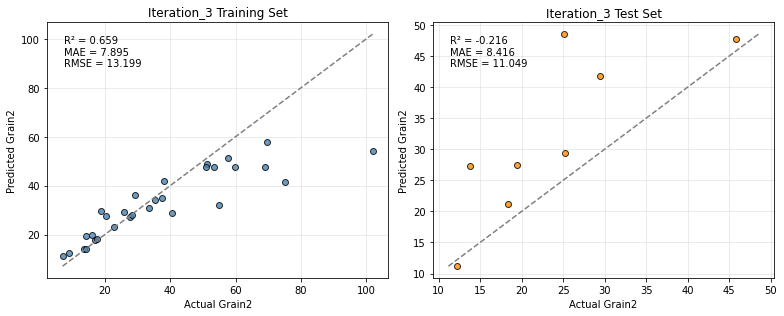


Iteration_4
Model performance in log space:
           R2     MAE    RMSE
Train  0.8613  0.1631  0.2381
Test  -0.2771  0.8037  0.8966


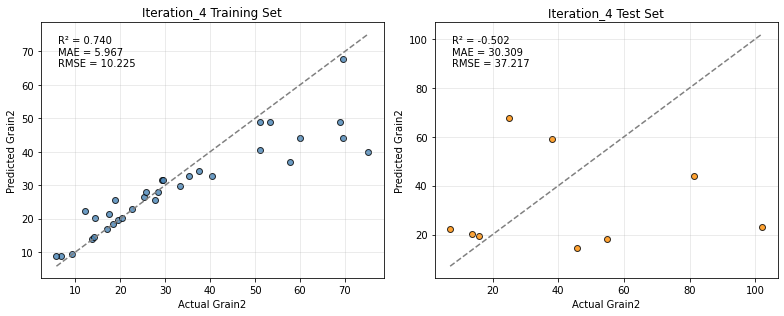


Iteration_5
Model performance in log space:
           R2     MAE    RMSE
Train  0.8565  0.2028  0.2625
Test  -0.1097  0.4405  0.5488


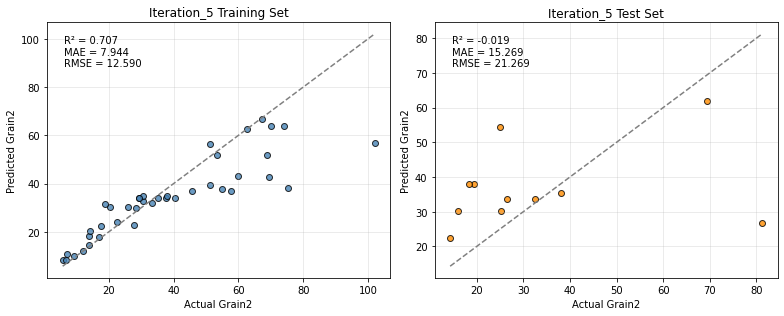


Iteration_6
Model performance in log space:
           R2     MAE    RMSE
Train  0.9014  0.1943  0.2538
Test   0.7259  0.5071  0.5713


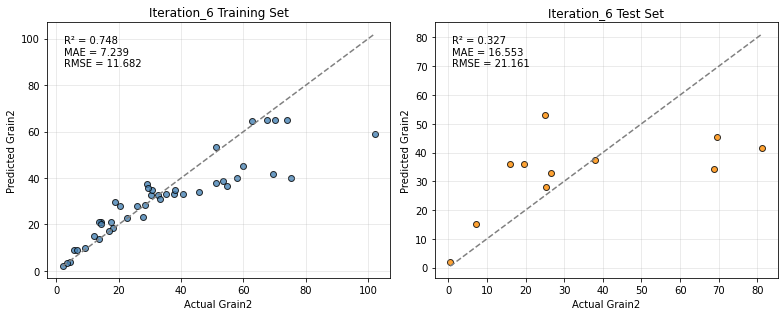

In [4]:
# ============================================================
# 4. Train and evaluate the models
# ============================================================

os.makedirs(
    "figure/grain2_iterations",
    exist_ok=True
)


# Calculate regression metrics in log space
def calculate_metrics(
    y_true_log,
    y_pred_log
):

    return {
        "R2": r2_score(
            y_true_log,
            y_pred_log
        ),
        "MAE": mean_absolute_error(
            y_true_log,
            y_pred_log
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true_log,
                y_pred_log
            )
        )
    }


# Store all iteration metrics
all_metrics = []


for iteration_name, iteration in iteration_data.items():

    X_train_selected = (
        iteration["X_train_selected"]
    )

    X_test_selected = (
        iteration["X_test_selected"]
    )

    y_train_log = (
        iteration["y_train_log"]
    )

    y_test_log = (
        iteration["y_test_log"]
    )


    # --------------------------------------------------------
    # Train the final model using log-transformed Grain2
    # --------------------------------------------------------

    reg = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=350,
        max_depth=3,
        learning_rate=0.05
    )

    reg.fit(
        X_train_selected,
        y_train_log
    )


    # Predictions remain in log space
    train_pred_log = reg.predict(
        X_train_selected
    )

    test_pred_log = reg.predict(
        X_test_selected
    )


    # Calculate metrics in log space
    train_metrics = calculate_metrics(
        y_train_log,
        train_pred_log
    )

    test_metrics = calculate_metrics(
        y_test_log,
        test_pred_log
    )

    metrics_table = pd.DataFrame(
        [train_metrics, test_metrics],
        index=["Train", "Test"]
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Model performance in log space:")
    print(
        metrics_table.round(4)
    )


    # Store train metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train_log),
        **train_metrics
    })

    # Store test metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test_log),
        **test_metrics
    })


    # Store model results
    iteration["reg"] = reg

    iteration["train_pred_log"] = (
        train_pred_log
    )

    iteration["test_pred_log"] = (
        test_pred_log
    )

    iteration["train_metrics"] = (
        train_metrics
    )

    iteration["test_metrics"] = (
        test_metrics
    )


    # --------------------------------------------------------
    # Convert predictions back to the original Grain2 scale
    # --------------------------------------------------------

    y_train_original = np.expm1(
        np.asarray(y_train_log)
    )

    y_test_original = np.expm1(
        np.asarray(y_test_log)
    )

    train_pred_original = np.expm1(
        train_pred_log
    )

    test_pred_original = np.expm1(
        test_pred_log
    )


    # Calculate metrics on the original Grain2 scale
    train_metrics_original = calculate_metrics(
        y_train_original,
        train_pred_original
    )

    test_metrics_original = calculate_metrics(
        y_test_original,
        test_pred_original
    )


    # Store original-scale results
    iteration["y_train_original"] = (
        y_train_original
    )

    iteration["y_test_original"] = (
        y_test_original
    )

    iteration["train_pred_original"] = (
        train_pred_original
    )

    iteration["test_pred_original"] = (
        test_pred_original
    )

    iteration["train_metrics_original"] = (
        train_metrics_original
    )

    iteration["test_metrics_original"] = (
        test_metrics_original
    )


    # --------------------------------------------------------
    # Plot model performance on the original Grain2 scale
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5)
    )


    # Training set
    axes[0].scatter(
        y_train_original,
        train_pred_original,
        color="steelblue",
        edgecolor="black",
        alpha=0.8
    )

    train_min = min(
        y_train_original.min(),
        train_pred_original.min()
    )

    train_max = max(
        y_train_original.max(),
        train_pred_original.max()
    )

    axes[0].plot(
        [train_min, train_max],
        [train_min, train_max],
        color="gray",
        linestyle="--"
    )

    axes[0].set_xlabel(
        "Actual Grain2"
    )

    axes[0].set_ylabel(
        "Predicted Grain2"
    )

    axes[0].set_title(
        f"{iteration_name} Training Set"
    )

    axes[0].text(
        0.05,
        0.95,
        (
            f"R² = {train_metrics_original['R2']:.3f}\n"
            f"MAE = {train_metrics_original['MAE']:.3f}\n"
            f"RMSE = {train_metrics_original['RMSE']:.3f}"
        ),
        transform=axes[0].transAxes,
        verticalalignment="top"
    )

    axes[0].grid(
        alpha=0.3
    )


    # Test set
    axes[1].scatter(
        y_test_original,
        test_pred_original,
        color="darkorange",
        edgecolor="black",
        alpha=0.8
    )

    test_min = min(
        y_test_original.min(),
        test_pred_original.min()
    )

    test_max = max(
        y_test_original.max(),
        test_pred_original.max()
    )

    axes[1].plot(
        [test_min, test_max],
        [test_min, test_max],
        color="gray",
        linestyle="--"
    )

    axes[1].set_xlabel(
        "Actual Grain2"
    )

    axes[1].set_ylabel(
        "Predicted Grain2"
    )

    axes[1].set_title(
        f"{iteration_name} Test Set"
    )

    axes[1].text(
        0.05,
        0.95,
        (
            f"R² = {test_metrics_original['R2']:.3f}\n"
            f"MAE = {test_metrics_original['MAE']:.3f}\n"
            f"RMSE = {test_metrics_original['RMSE']:.3f}"
        ),
        transform=axes[1].transAxes,
        verticalalignment="top"
    )

    axes[1].grid(
        alpha=0.3
    )


    plt.tight_layout()

    plt.show()

In [5]:
# ============================================================
# 5. Save models, selected features and original-scale results
# ============================================================

os.makedirs(
    "model/grain2_iterations",
    exist_ok=True
)

os.makedirs(
    "result/grain2_iterations",
    exist_ok=True
)


# Store metrics on the original Grain2 scale
all_metrics_original = []


for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    reg = iteration["reg"]

    selected_features = (
        iteration["selected_features"]
    )

    y_train_log = (
        iteration["y_train_log"]
    )

    y_test_log = (
        iteration["y_test_log"]
    )

    train_pred_log = (
        iteration["train_pred_log"]
    )

    test_pred_log = (
        iteration["test_pred_log"]
    )


    # --------------------------------------------------------
    # Convert values back to the original Grain2 scale
    # --------------------------------------------------------

    y_train_original = np.expm1(
        np.asarray(y_train_log)
    )

    y_test_original = np.expm1(
        np.asarray(y_test_log)
    )

    train_pred_original = np.expm1(
        train_pred_log
    )

    test_pred_original = np.expm1(
        test_pred_log
    )


    # Calculate metrics on the original Grain2 scale
    train_metrics_original = calculate_metrics(
        y_train_original,
        train_pred_original
    )

    test_metrics_original = calculate_metrics(
        y_test_original,
        test_pred_original
    )


    # Store original-scale metrics
    all_metrics_original.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train_original),
        **train_metrics_original
    })

    all_metrics_original.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test_original),
        **test_metrics_original
    })


    # --------------------------------------------------------
    # Save model
    # --------------------------------------------------------

    joblib.dump(
        reg,
        (
            "model/grain2_iterations/"
            f"xgb_structural_grain2_{iteration_number}.pkl"
        )
    )


    # --------------------------------------------------------
    # Save selected features
    # --------------------------------------------------------

    np.save(
        (
            "model/grain2_iterations/"
            f"selected_features_structural_grain2_"
            f"{iteration_number}.npy"
        ),
        np.array(selected_features)
    )


    # --------------------------------------------------------
    # Save training predictions on the original scale
    # --------------------------------------------------------

    train_predictions = pd.DataFrame({
        "Actual_Grain2": y_train_original,
        "Predicted_Grain2": train_pred_original
    })

    train_predictions.to_csv(
        (
            "result/grain2_iterations/"
            f"Iteration_{iteration_number}_"
            "train_predictions.csv"
        ),
        index=False
    )


    # --------------------------------------------------------
    # Save test predictions on the original scale
    # --------------------------------------------------------

    test_predictions = pd.DataFrame({
        "Actual_Grain2": y_test_original,
        "Predicted_Grain2": test_pred_original
    })

    test_predictions.to_csv(
        (
            "result/grain2_iterations/"
            f"Iteration_{iteration_number}_"
            "test_predictions.csv"
        ),
        index=False
    )


    print(
        f"Iteration_{iteration_number} files saved."
    )


# ============================================================
# Save all iteration metrics on the original scale
# ============================================================

all_metrics_original_table = pd.DataFrame(
    all_metrics_original
)

all_metrics_original_table.to_csv(
    (
        "result/grain2_iterations/"
        "grain2_iteration_metrics_original.csv"
    ),
    index=False
)


# ============================================================
# Display test-set comparison on the original scale
# ============================================================

test_metrics_table = (
    all_metrics_original_table[
        all_metrics_original_table["Dataset"] == "Test"
    ]
    .reset_index(drop=True)
)


print("\n" + "=" * 70)
print("Test performance comparison on the original Grain2 scale")
print("=" * 70)

print(
    test_metrics_table.round(4)
)

Iteration_3 files saved.
Iteration_4 files saved.
Iteration_5 files saved.
Iteration_6 files saved.

Test performance comparison on the original Grain2 scale
     Iteration Dataset  Sample_Size      R2      MAE     RMSE
0  Iteration_3    Test            8 -0.2157   8.4159  11.0487
1  Iteration_4    Test            9 -0.5016  30.3092  37.2173
2  Iteration_5    Test           11 -0.0192  15.2690  21.2687
3  Iteration_6    Test           11  0.3265  16.5529  21.1612


## a2

In [1]:
# ============================================================
# 1. Import packages
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
# ============================================================
# 2. Load data and randomly split each dataset
# ============================================================

DATA_FILES = {
    "Iteration_3": "data/compound_3_Structural_a2.csv",
    "Iteration_4": "data/compound_4_Structural_a2.csv",
    "Iteration_5": "data/compound_5_Structural_a2.csv",
    "Iteration_6": "data/compound_6_Structural_a2.csv"
}

TARGET_COL = "a_2"
COMPOUND_COL = "compound"

RANDOM_STATE = 42
TEST_SIZE = 0.20


# Store data from all iterations
iteration_data = {}


for iteration_name, data_file in DATA_FILES.items():

    # Load data
    data = pd.read_csv(data_file)

    # Remove automatically generated index columns
    data = data.loc[
        :,
        ~data.columns.str.startswith("Unnamed")
    ].copy()

    # Features
    X = (
        data
        .drop(
            columns=[
                TARGET_COL,
                COMPOUND_COL
            ],
            errors="ignore"
        )
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )

    # Target
    y = (
        data[TARGET_COL]
        .astype(float)
    )

    # Randomly split each dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # Store the current iteration data
    iteration_data[iteration_name] = {
        "data_file": data_file,
        "data": data,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Dataset shape:", data.shape)
    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))

    print(
        "Training target range:",
        round(y_train.min(), 4),
        "to",
        round(y_train.max(), 4)
    )

    print(
        "Test target range:",
        round(y_test.min(), 4),
        "to",
        round(y_test.max(), 4)
    )




Iteration_3
Dataset shape: (38, 27)
Training samples: 30
Test samples: 8
Training target range: 2.7189 to 10.1342
Test target range: 3.6943 to 8.3566

Iteration_4
Dataset shape: (42, 27)
Training samples: 33
Test samples: 9
Training target range: 2.7189 to 10.1342
Test target range: 3.6943 to 10.1153

Iteration_5
Dataset shape: (51, 27)
Training samples: 40
Test samples: 11
Training target range: 2.7189 to 10.1342
Test target range: 3.9295 to 9.3786

Iteration_6
Dataset shape: (55, 27)
Training samples: 44
Test samples: 11
Training target range: 2.7189 to 10.1342
Test target range: 3.9524 to 10.1153


In [3]:
# ============================================================
# 3. Feature selection
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]
    y_train = iteration["y_train"]

    # Initial model for feature selection
    reg_selector = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1
    )

    reg_selector.fit(
        X_train,
        y_train
    )

    # Extract feature importance
    feature_importance = (
        reg_selector.feature_importances_
    )

    feature_names = (
        X_train.columns.to_numpy()
    )

    # Keep the top 15 features
    num_features_to_keep = min(
        15,
        X_train.shape[1]
    )

    top_idx = np.argsort(
        feature_importance
    )[::-1][:num_features_to_keep]

    selected_features = (
        feature_names[top_idx]
        .tolist()
    )

    # Select training and test features
    X_train_selected = (
        X_train[selected_features]
        .copy()
    )

    X_test_selected = (
        X_test[selected_features]
        .copy()
    )

    # Store feature-selection results
    iteration["reg_selector"] = reg_selector

    iteration["selected_features"] = (
        selected_features
    )

    iteration["X_train_selected"] = (
        X_train_selected
    )

    iteration["X_test_selected"] = (
        X_test_selected
    )

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Selected features:")
    print(selected_features)



Iteration_3
Selected features:
['AB_SIE', 'AB_Nd', 'AB_EN', 'AB_CR', 'AB_D', 'AB_AN', 'AB_EC', 'AB_TC', 'AB_EA', 'AB_Nv', 'AB_FIE', 'AB_AR', 'C_AR', 'C_EA', 'AB_AW']

Iteration_4
Selected features:
['C_EA', 'AB_EN', 'AB_D', 'AB_Nv', 'AB_EA', 'AB_SIE', 'AB_AN', 'AB_EC', 'AB_TC', 'C_AN', 'AB_CR', 'AB_Nd', 'AB_FIE', 'AB_AR', 'C_CR']

Iteration_5
Selected features:
['C_EA', 'AB_EN', 'AB_D', 'AB_Nv', 'AB_FIE', 'AB_EA', 'AB_CR', 'AB_SIE', 'AB_Nd', 'AB_TC', 'AB_AR', 'C_SIE', 'AB_AN', 'AB_EC', 'C_Nv']

Iteration_6
Selected features:
['C_EA', 'AB_EN', 'AB_Nd', 'AB_D', 'AB_FIE', 'AB_Nv', 'AB_EA', 'AB_SIE', 'AB_AN', 'AB_TC', 'C_SIE', 'AB_CR', 'AB_AR', 'AB_EC', 'C_AN']



Iteration_3
Model performance:
           R2     MAE    RMSE
Train  0.9954  0.1088  0.1526
Test   0.6889  0.5536  0.8058


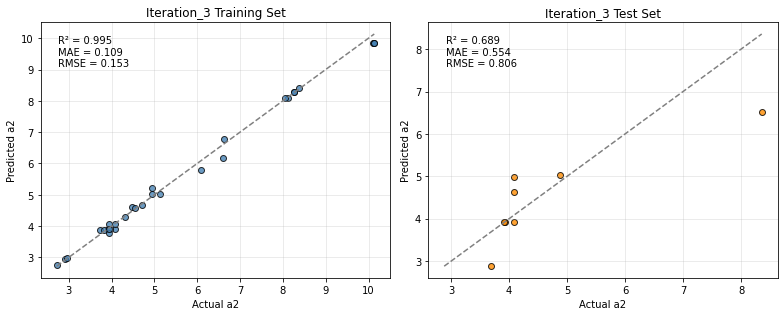


Iteration_4
Model performance:
           R2     MAE    RMSE
Train  0.9941  0.0973  0.1717
Test   0.7497  0.8168  1.0695


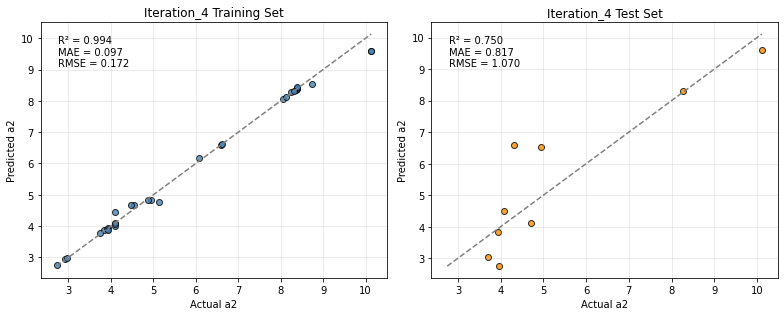


Iteration_5
Model performance:
           R2     MAE    RMSE
Train  0.9944  0.1147  0.1722
Test   0.5908  0.6399  1.4172


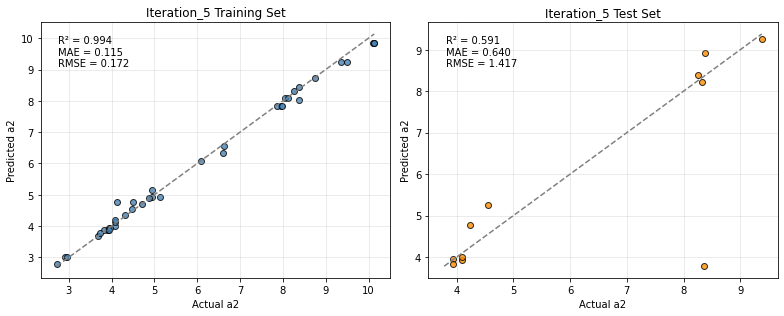


Iteration_6
Model performance:
           R2     MAE    RMSE
Train  0.9922  0.1425  0.1956
Test   0.8814  0.6059  0.7790


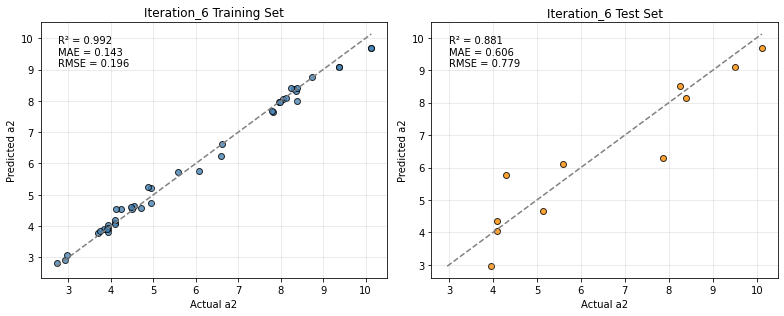

In [4]:
# ============================================================
# 4. Train and evaluate the models
# ============================================================

os.makedirs(
    "figure/a2_iterations",
    exist_ok=True
)


def calculate_metrics(
    y_true,
    y_pred
):

    return {
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    }


# Store all iteration metrics
all_metrics = []


for iteration_name, iteration in iteration_data.items():

    X_train_selected = (
        iteration["X_train_selected"]
    )

    X_test_selected = (
        iteration["X_test_selected"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]


    # Train the final model
    reg = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05
    )

    reg.fit(
        X_train_selected,
        y_train
    )


    # Predictions
    train_pred = reg.predict(
        X_train_selected
    )

    test_pred = reg.predict(
        X_test_selected
    )


    # Calculate metrics using original a2 values
    train_metrics = calculate_metrics(
        y_train,
        train_pred
    )

    test_metrics = calculate_metrics(
        y_test,
        test_pred
    )

    metrics_table = pd.DataFrame(
        [train_metrics, test_metrics],
        index=["Train", "Test"]
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Model performance:")
    print(
        metrics_table.round(4)
    )


    # Store metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train),
        **train_metrics
    })

    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test),
        **test_metrics
    })


    # Store model results
    iteration["reg"] = reg
    iteration["train_pred"] = train_pred
    iteration["test_pred"] = test_pred
    iteration["train_metrics"] = train_metrics
    iteration["test_metrics"] = test_metrics


    # ========================================================
    # Plot model performance
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5)
    )


    # Training set
    axes[0].scatter(
        y_train,
        train_pred,
        color="steelblue",
        edgecolor="black",
        alpha=0.8
    )

    train_min = min(
        y_train.min(),
        train_pred.min()
    )

    train_max = max(
        y_train.max(),
        train_pred.max()
    )

    axes[0].plot(
        [train_min, train_max],
        [train_min, train_max],
        color="gray",
        linestyle="--"
    )

    axes[0].set_xlabel("Actual a2")
    axes[0].set_ylabel("Predicted a2")

    axes[0].set_title(
        f"{iteration_name} Training Set"
    )

    axes[0].text(
        0.05,
        0.95,
        (
            f"R² = {train_metrics['R2']:.3f}\n"
            f"MAE = {train_metrics['MAE']:.3f}\n"
            f"RMSE = {train_metrics['RMSE']:.3f}"
        ),
        transform=axes[0].transAxes,
        verticalalignment="top"
    )

    axes[0].grid(alpha=0.3)


    # Test set
    axes[1].scatter(
        y_test,
        test_pred,
        color="darkorange",
        edgecolor="black",
        alpha=0.8
    )

    test_min = min(
        y_test.min(),
        test_pred.min()
    )

    test_max = max(
        y_test.max(),
        test_pred.max()
    )

    axes[1].plot(
        [test_min, test_max],
        [test_min, test_max],
        color="gray",
        linestyle="--"
    )

    axes[1].set_xlabel("Actual a2")
    axes[1].set_ylabel("Predicted a2")

    axes[1].set_title(
        f"{iteration_name} Test Set"
    )

    axes[1].text(
        0.05,
        0.95,
        (
            f"R² = {test_metrics['R2']:.3f}\n"
            f"MAE = {test_metrics['MAE']:.3f}\n"
            f"RMSE = {test_metrics['RMSE']:.3f}"
        ),
        transform=axes[1].transAxes,
        verticalalignment="top"
    )

    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


In [5]:
# ============================================================
# 5. Save models, selected features and results
# ============================================================

os.makedirs(
    "model/a2_iterations",
    exist_ok=True
)

os.makedirs(
    "result/a2_iterations",
    exist_ok=True
)


for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    reg = iteration["reg"]

    selected_features = (
        iteration["selected_features"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    train_pred = iteration["train_pred"]
    test_pred = iteration["test_pred"]


    # Save model
    joblib.dump(
        reg,
        (
            "model/a2_iterations/"
            f"xgb_structural_a2_{iteration_number}.pkl"
        )
    )


    # Save selected features
    np.save(
        (
            "model/a2_iterations/"
            f"selected_features_structural_a2_"
            f"{iteration_number}.npy"
        ),
        np.array(selected_features)
    )


    # Save training predictions
    train_predictions = pd.DataFrame({
        "Actual_a2": np.asarray(y_train),
        "Predicted_a2": train_pred
    })

    train_predictions.to_csv(
        (
            "result/a2_iterations/"
            f"Iteration_{iteration_number}_"
            "train_predictions.csv"
        ),
        index=False
    )


    # Save test predictions
    test_predictions = pd.DataFrame({
        "Actual_a2": np.asarray(y_test),
        "Predicted_a2": test_pred
    })

    test_predictions.to_csv(
        (
            "result/a2_iterations/"
            f"Iteration_{iteration_number}_"
            "test_predictions.csv"
        ),
        index=False
    )

    print(
        f"Iteration_{iteration_number} files saved."
    )


# Save all iteration metrics
all_metrics_table = pd.DataFrame(
    all_metrics
)

all_metrics_table.to_csv(
    "result/a2_iterations/"
    "a2_iteration_metrics.csv",
    index=False
)


# Display test-set comparison
test_metrics_table = (
    all_metrics_table[
        all_metrics_table["Dataset"] == "Test"
    ]
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("Test performance comparison")
print("=" * 70)

print(
    test_metrics_table.round(4)
)

Iteration_3 files saved.
Iteration_4 files saved.
Iteration_5 files saved.
Iteration_6 files saved.

Test performance comparison
     Iteration Dataset  Sample_Size      R2     MAE    RMSE
0  Iteration_3    Test            8  0.6889  0.5536  0.8058
1  Iteration_4    Test            9  0.7497  0.8168  1.0695
2  Iteration_5    Test           11  0.5908  0.6399  1.4172
3  Iteration_6    Test           11  0.8814  0.6059  0.7790


## b2

In [1]:
# ============================================================
# 1. Import packages
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
# ============================================================
# 2. Load data and randomly split each dataset
# ============================================================

DATA_FILES = {
    "Iteration_3": "data/compound_3_Structural_b2.csv",
    "Iteration_4": "data/compound_4_Structural_b2.csv",
    "Iteration_5": "data/compound_5_Structural_b2.csv",
    "Iteration_6": "data/compound_6_Structural_b2.csv"
}

TARGET_COL = "b_2"
COMPOUND_COL = "compound"

RANDOM_STATE = 42
TEST_SIZE = 0.20


# Store data from all iterations
iteration_data = {}


for iteration_name, data_file in DATA_FILES.items():

    # Load data
    data = pd.read_csv(data_file)

    # Remove automatically generated index columns
    data = data.loc[
        :,
        ~data.columns.str.startswith("Unnamed")
    ].copy()

    # Features
    X = (
        data
        .drop(
            columns=[
                TARGET_COL,
                COMPOUND_COL
            ],
            errors="ignore"
        )
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )

    # Target
    y = (
        data[TARGET_COL]
        .astype(float)
    )

    # Randomly split each dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # Store the current iteration data
    iteration_data[iteration_name] = {
        "data_file": data_file,
        "data": data,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Dataset shape:", data.shape)
    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))

    print(
        "Training target range:",
        round(y_train.min(), 4),
        "to",
        round(y_train.max(), 4)
    )

    print(
        "Test target range:",
        round(y_test.min(), 4),
        "to",
        round(y_test.max(), 4)
    )




Iteration_3
Dataset shape: (38, 27)
Training samples: 30
Test samples: 8
Training target range: 2.7189 to 10.1342
Test target range: 3.6943 to 8.3566

Iteration_4
Dataset shape: (42, 27)
Training samples: 33
Test samples: 9
Training target range: 2.7189 to 10.1342
Test target range: 3.6943 to 10.1153

Iteration_5
Dataset shape: (51, 27)
Training samples: 40
Test samples: 11
Training target range: 2.7189 to 10.1342
Test target range: 3.9295 to 9.3786

Iteration_6
Dataset shape: (55, 27)
Training samples: 44
Test samples: 11
Training target range: 2.7189 to 10.1342
Test target range: 3.9524 to 10.1153


In [3]:
# ============================================================
# 3. Feature selection
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]
    y_train = iteration["y_train"]

    # Initial model for feature selection
    reg_selector = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1
    )

    reg_selector.fit(
        X_train,
        y_train
    )

    # Extract feature importance
    feature_importance = (
        reg_selector.feature_importances_
    )

    feature_names = (
        X_train.columns.to_numpy()
    )

    # Keep the top 15 features
    num_features_to_keep = min(
        15,
        X_train.shape[1]
    )

    top_idx = np.argsort(
        feature_importance
    )[::-1][:num_features_to_keep]

    selected_features = (
        feature_names[top_idx]
        .tolist()
    )

    # Select training and test features
    X_train_selected = (
        X_train[selected_features]
        .copy()
    )

    X_test_selected = (
        X_test[selected_features]
        .copy()
    )

    # Store feature-selection results
    iteration["reg_selector"] = reg_selector

    iteration["selected_features"] = (
        selected_features
    )

    iteration["X_train_selected"] = (
        X_train_selected
    )

    iteration["X_test_selected"] = (
        X_test_selected
    )

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Selected features:")
    print(selected_features)



Iteration_3
Selected features:
['AB_SIE', 'AB_Nd', 'AB_EN', 'AB_CR', 'AB_D', 'AB_AN', 'AB_EC', 'AB_TC', 'AB_EA', 'AB_Nv', 'AB_FIE', 'AB_AR', 'C_AR', 'C_EA', 'AB_AW']

Iteration_4
Selected features:
['C_EA', 'AB_EN', 'AB_D', 'AB_Nv', 'AB_EA', 'AB_SIE', 'AB_AN', 'AB_EC', 'AB_TC', 'C_AN', 'AB_CR', 'AB_Nd', 'AB_FIE', 'AB_AR', 'C_CR']

Iteration_5
Selected features:
['C_EA', 'AB_EN', 'AB_D', 'AB_Nv', 'AB_EA', 'AB_CR', 'AB_Nd', 'AB_SIE', 'AB_TC', 'AB_EC', 'AB_FIE', 'AB_AN', 'AB_AR', 'C_Nv', 'C_AN']

Iteration_6
Selected features:
['C_EA', 'AB_EN', 'AB_D', 'AB_Nv', 'AB_Nd', 'AB_EA', 'C_AN', 'AB_AN', 'AB_FIE', 'AB_CR', 'AB_TC', 'AB_SIE', 'AB_AR', 'AB_EC', 'AB_AW']



Iteration_3
Model performance:
           R2     MAE    RMSE
Train  0.9954  0.1088  0.1526
Test   0.6889  0.5536  0.8058


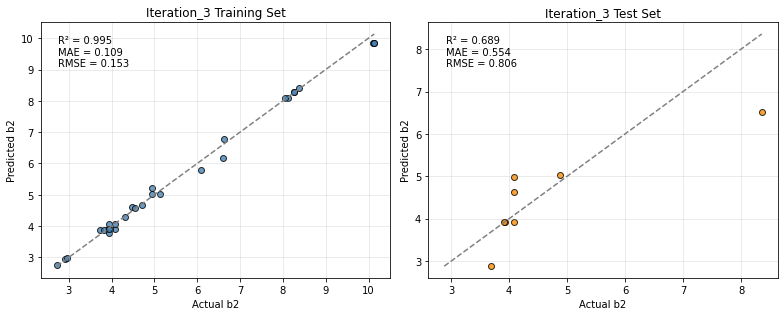


Iteration_4
Model performance:
           R2     MAE    RMSE
Train  0.9941  0.0973  0.1717
Test   0.7497  0.8168  1.0695


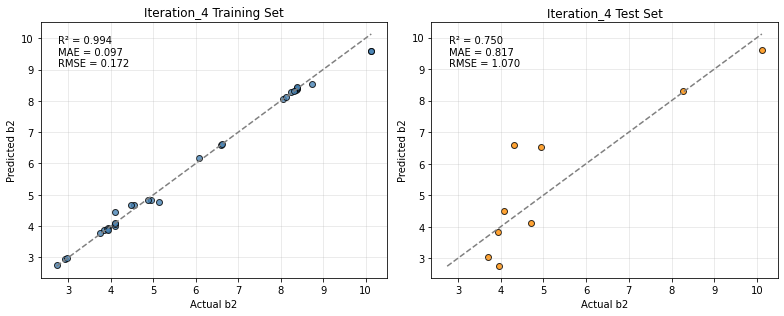


Iteration_5
Model performance:
           R2     MAE    RMSE
Train  0.9937  0.1350  0.1809
Test   0.5103  0.7643  1.4973


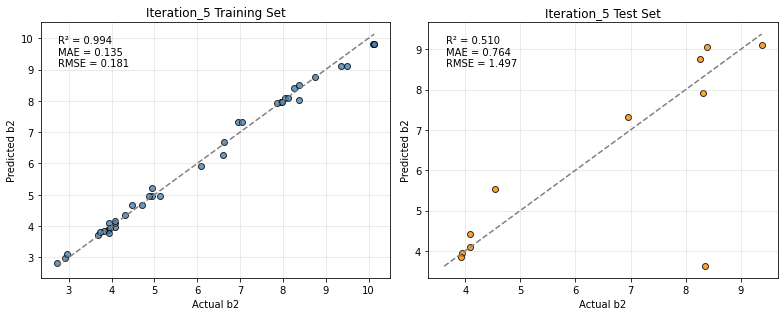


Iteration_6
Model performance:
           R2     MAE    RMSE
Train  0.9921  0.1513  0.1935
Test   0.9175  0.4916  0.6498


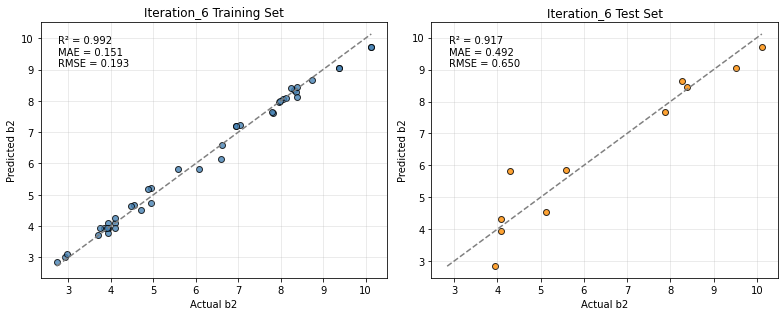

In [4]:
# ============================================================
# 4. Train and evaluate the models
# ============================================================

os.makedirs(
    "figure/b2_iterations",
    exist_ok=True
)


def calculate_metrics(
    y_true,
    y_pred
):

    return {
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    }


# Store all iteration metrics
all_metrics = []


for iteration_name, iteration in iteration_data.items():

    X_train_selected = (
        iteration["X_train_selected"]
    )

    X_test_selected = (
        iteration["X_test_selected"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]


    # Train the final model
    reg = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05
    )

    reg.fit(
        X_train_selected,
        y_train
    )


    # Predictions
    train_pred = reg.predict(
        X_train_selected
    )

    test_pred = reg.predict(
        X_test_selected
    )


    # Calculate metrics using original b2 values
    train_metrics = calculate_metrics(
        y_train,
        train_pred
    )

    test_metrics = calculate_metrics(
        y_test,
        test_pred
    )

    metrics_table = pd.DataFrame(
        [train_metrics, test_metrics],
        index=["Train", "Test"]
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Model performance:")
    print(
        metrics_table.round(4)
    )


    # Store metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train),
        **train_metrics
    })

    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test),
        **test_metrics
    })


    # Store model results
    iteration["reg"] = reg
    iteration["train_pred"] = train_pred
    iteration["test_pred"] = test_pred
    iteration["train_metrics"] = train_metrics
    iteration["test_metrics"] = test_metrics


    # ========================================================
    # Plot model performance
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5)
    )


    # Training set
    axes[0].scatter(
        y_train,
        train_pred,
        color="steelblue",
        edgecolor="black",
        alpha=0.8
    )

    train_min = min(
        y_train.min(),
        train_pred.min()
    )

    train_max = max(
        y_train.max(),
        train_pred.max()
    )

    axes[0].plot(
        [train_min, train_max],
        [train_min, train_max],
        color="gray",
        linestyle="--"
    )

    axes[0].set_xlabel("Actual b2")
    axes[0].set_ylabel("Predicted b2")

    axes[0].set_title(
        f"{iteration_name} Training Set"
    )

    axes[0].text(
        0.05,
        0.95,
        (
            f"R² = {train_metrics['R2']:.3f}\n"
            f"MAE = {train_metrics['MAE']:.3f}\n"
            f"RMSE = {train_metrics['RMSE']:.3f}"
        ),
        transform=axes[0].transAxes,
        verticalalignment="top"
    )

    axes[0].grid(alpha=0.3)


    # Test set
    axes[1].scatter(
        y_test,
        test_pred,
        color="darkorange",
        edgecolor="black",
        alpha=0.8
    )

    test_min = min(
        y_test.min(),
        test_pred.min()
    )

    test_max = max(
        y_test.max(),
        test_pred.max()
    )

    axes[1].plot(
        [test_min, test_max],
        [test_min, test_max],
        color="gray",
        linestyle="--"
    )

    axes[1].set_xlabel("Actual b2")
    axes[1].set_ylabel("Predicted b2")

    axes[1].set_title(
        f"{iteration_name} Test Set"
    )

    axes[1].text(
        0.05,
        0.95,
        (
            f"R² = {test_metrics['R2']:.3f}\n"
            f"MAE = {test_metrics['MAE']:.3f}\n"
            f"RMSE = {test_metrics['RMSE']:.3f}"
        ),
        transform=axes[1].transAxes,
        verticalalignment="top"
    )

    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


In [5]:
# ============================================================
# 5. Save models, selected features and results
# ============================================================

os.makedirs(
    "model/b2_iterations",
    exist_ok=True
)

os.makedirs(
    "result/b2_iterations",
    exist_ok=True
)


for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    reg = iteration["reg"]

    selected_features = (
        iteration["selected_features"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    train_pred = iteration["train_pred"]
    test_pred = iteration["test_pred"]


    # Save model
    joblib.dump(
        reg,
        (
            "model/b2_iterations/"
            f"xgb_structural_b2_{iteration_number}.pkl"
        )
    )


    # Save selected features
    np.save(
        (
            "model/b2_iterations/"
            f"selected_features_structural_b2_"
            f"{iteration_number}.npy"
        ),
        np.array(selected_features)
    )


    # Save training predictions
    train_predictions = pd.DataFrame({
        "Actual_b2": np.asarray(y_train),
        "Predicted_b2": train_pred
    })

    train_predictions.to_csv(
        (
            "result/b2_iterations/"
            f"Iteration_{iteration_number}_"
            "train_predictions.csv"
        ),
        index=False
    )


    # Save test predictions
    test_predictions = pd.DataFrame({
        "Actual_b2": np.asarray(y_test),
        "Predicted_b2": test_pred
    })

    test_predictions.to_csv(
        (
            "result/b2_iterations/"
            f"Iteration_{iteration_number}_"
            "test_predictions.csv"
        ),
        index=False
    )

    print(
        f"Iteration_{iteration_number} files saved."
    )


# Save all iteration metrics
all_metrics_table = pd.DataFrame(
    all_metrics
)

all_metrics_table.to_csv(
    "result/b2_iterations/"
    "b2_iteration_metrics.csv",
    index=False
)


# Display test-set comparison
test_metrics_table = (
    all_metrics_table[
        all_metrics_table["Dataset"] == "Test"
    ]
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("Test performance comparison")
print("=" * 70)

print(
    test_metrics_table.round(4)
)

Iteration_3 files saved.
Iteration_4 files saved.
Iteration_5 files saved.
Iteration_6 files saved.

Test performance comparison
     Iteration Dataset  Sample_Size      R2     MAE    RMSE
0  Iteration_3    Test            8  0.6889  0.5536  0.8058
1  Iteration_4    Test            9  0.7497  0.8168  1.0695
2  Iteration_5    Test           11  0.5103  0.7643  1.4973
3  Iteration_6    Test           11  0.9175  0.4916  0.6498


## c2

In [1]:
# ============================================================
# 1. Import packages
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [2]:
# ============================================================
# 2. Load data and randomly split each dataset
# ============================================================

DATA_FILES = {
    "Iteration_3": "data/compound_3_Structural_c2.csv",
    "Iteration_4": "data/compound_4_Structural_c2.csv",
    "Iteration_5": "data/compound_5_Structural_c2.csv",
    "Iteration_6": "data/compound_6_Structural_c2.csv"
}

TARGET_COL = "c_2"
COMPOUND_COL = "compound"

RANDOM_STATE = 1100
TEST_SIZE = 0.20


# Store data from all iterations
iteration_data = {}


for iteration_name, data_file in DATA_FILES.items():

    # Load data
    data = pd.read_csv(data_file)

    # Remove automatically generated index columns
    data = data.loc[
        :,
        ~data.columns.str.startswith("Unnamed")
    ].copy()

    # Features
    X = (
        data
        .drop(
            columns=[
                TARGET_COL,
                COMPOUND_COL
            ],
            errors="ignore"
        )
        .apply(
            pd.to_numeric,
            errors="raise"
        )
    )

    # Target
    y = (
        data[TARGET_COL]
        .astype(float)
    )

    # Randomly split each dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    # Store the current iteration data
    iteration_data[iteration_name] = {
        "data_file": data_file,
        "data": data,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Dataset shape:", data.shape)
    print("Training samples:", len(X_train))
    print("Test samples:", len(X_test))

    print(
        "Training target range:",
        round(y_train.min(), 4),
        "to",
        round(y_train.max(), 4)
    )

    print(
        "Test target range:",
        round(y_test.min(), 4),
        "to",
        round(y_test.max(), 4)
    )




Iteration_3
Dataset shape: (38, 27)
Training samples: 30
Test samples: 8
Training target range: 3.133 to 18.0213
Test target range: 3.1019 to 13.5987

Iteration_4
Dataset shape: (42, 27)
Training samples: 33
Test samples: 9
Training target range: 3.1019 to 18.0213
Test target range: 3.133 to 10.1342

Iteration_5
Dataset shape: (51, 27)
Training samples: 40
Test samples: 11
Training target range: 3.1019 to 18.0213
Test target range: 3.8283 to 10.121

Iteration_6
Dataset shape: (55, 27)
Training samples: 44
Test samples: 11
Training target range: 3.1019 to 31.7051
Test target range: 3.9137 to 31.8259


In [3]:
# ============================================================
# 3. Feature selection
# ============================================================

for iteration_name, iteration in iteration_data.items():

    X_train = iteration["X_train"]
    X_test = iteration["X_test"]
    y_train = iteration["y_train"]

    # Initial model for feature selection
    reg_selector = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1
    )

    reg_selector.fit(
        X_train,
        y_train
    )

    # Extract feature importance
    feature_importance = (
        reg_selector.feature_importances_
    )

    feature_names = (
        X_train.columns.to_numpy()
    )

    # Keep the top 10 features
    num_features_to_keep = min(
        10,
        X_train.shape[1]
    )

    top_idx = np.argsort(
        feature_importance
    )[::-1][:num_features_to_keep]

    selected_features = (
        feature_names[top_idx]
        .tolist()
    )

    # Select training and test features
    X_train_selected = (
        X_train[selected_features]
        .copy()
    )

    X_test_selected = (
        X_test[selected_features]
        .copy()
    )

    # Store feature-selection results
    iteration["reg_selector"] = reg_selector

    iteration["selected_features"] = (
        selected_features
    )

    iteration["X_train_selected"] = (
        X_train_selected
    )

    iteration["X_test_selected"] = (
        X_test_selected
    )

    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Selected features:")
    print(selected_features)



Iteration_3
Selected features:
['AB_D', 'AB_Nd', 'AB_EA', 'AB_SIE', 'AB_EN', 'AB_FIE', 'AB_CR', 'AB_AN', 'AB_AR', 'AB_TC']

Iteration_4
Selected features:
['AB_Nd', 'AB_EN', 'AB_EA', 'C_AN', 'AB_D', 'AB_EC', 'AB_CR', 'AB_AN', 'AB_FIE', 'AB_SIE']

Iteration_5
Selected features:
['AB_EN', 'AB_Nd', 'AB_EA', 'C_EA', 'AB_D', 'AB_CR', 'AB_AN', 'AB_Nv', 'AB_FIE', 'AB_SIE']

Iteration_6
Selected features:
['AB_Nv', 'C_AW', 'AB_Nd', 'AB_EN', 'AB_CR', 'AB_AN', 'AB_EA', 'C_EA', 'AB_D', 'AB_FIE']



Iteration_3
Model performance:
           R2     MAE    RMSE
Train  0.9900  0.2223  0.3635
Test   0.4495  1.5856  2.7723


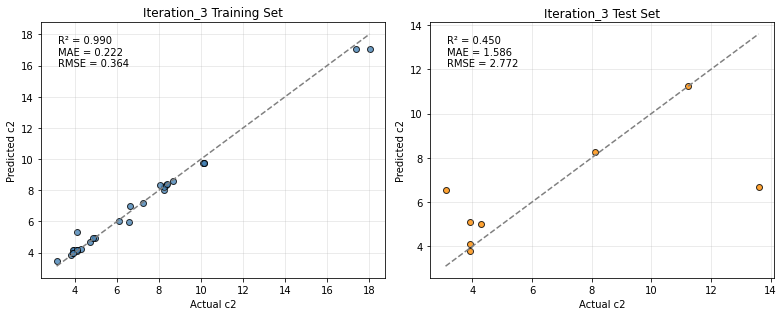


Iteration_4
Model performance:
           R2     MAE    RMSE
Train  0.9854  0.2636  0.4510
Test   0.8237  0.8143  1.0272


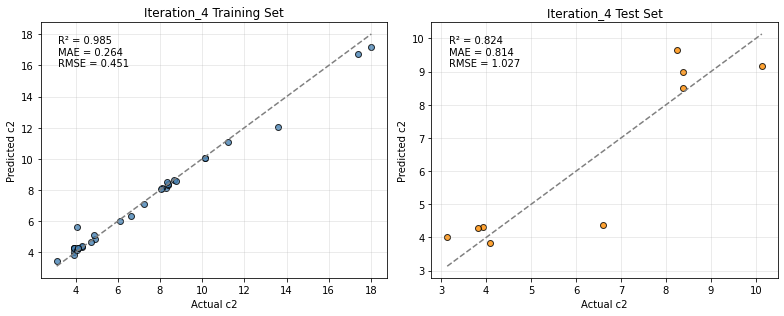


Iteration_5
Model performance:
           R2     MAE    RMSE
Train  0.9898  0.2198  0.3483
Test   0.0523  1.3608  2.3015


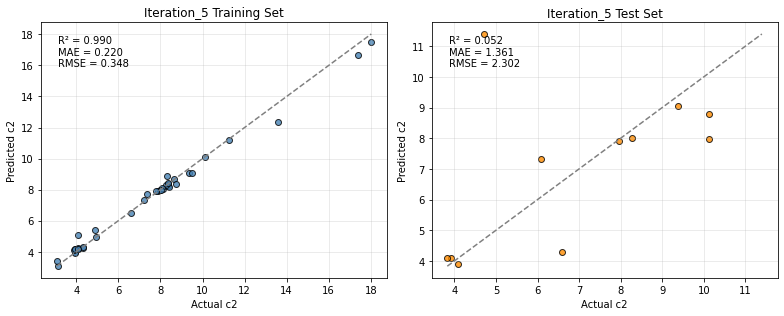


Iteration_6
Model performance:
           R2     MAE    RMSE
Train  0.9943  0.2673  0.3710
Test   0.8909  1.8502  2.5192


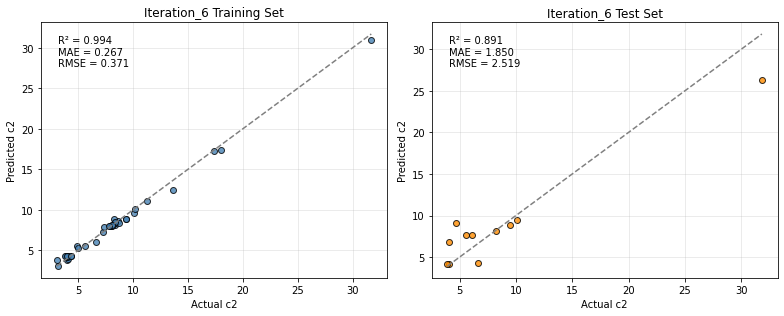

In [4]:
# ============================================================
# 4. Train and evaluate the models
# ============================================================

os.makedirs(
    "figure/c2_iterations",
    exist_ok=True
)


def calculate_metrics(
    y_true,
    y_pred
):

    return {
        "R2": r2_score(
            y_true,
            y_pred
        ),
        "MAE": mean_absolute_error(
            y_true,
            y_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred
            )
        )
    }


# Store all iteration metrics
all_metrics = []


for iteration_name, iteration in iteration_data.items():

    X_train_selected = (
        iteration["X_train_selected"]
    )

    X_test_selected = (
        iteration["X_test_selected"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]


    # Train the final model
    reg = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        reg_alpha=1,
        reg_lambda=1,
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05
    )

    reg.fit(
        X_train_selected,
        y_train
    )


    # Predictions
    train_pred = reg.predict(
        X_train_selected
    )

    test_pred = reg.predict(
        X_test_selected
    )


    # Calculate metrics using original c2 values
    train_metrics = calculate_metrics(
        y_train,
        train_pred
    )

    test_metrics = calculate_metrics(
        y_test,
        test_pred
    )

    metrics_table = pd.DataFrame(
        [train_metrics, test_metrics],
        index=["Train", "Test"]
    )


    print("\n" + "=" * 70)
    print(iteration_name)
    print("=" * 70)

    print("Model performance:")
    print(
        metrics_table.round(4)
    )


    # Store metrics
    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Train",
        "Sample_Size": len(y_train),
        **train_metrics
    })

    all_metrics.append({
        "Iteration": iteration_name,
        "Dataset": "Test",
        "Sample_Size": len(y_test),
        **test_metrics
    })


    # Store model results
    iteration["reg"] = reg
    iteration["train_pred"] = train_pred
    iteration["test_pred"] = test_pred
    iteration["train_metrics"] = train_metrics
    iteration["test_metrics"] = test_metrics


    # ========================================================
    # Plot model performance
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5)
    )


    # Training set
    axes[0].scatter(
        y_train,
        train_pred,
        color="steelblue",
        edgecolor="black",
        alpha=0.8
    )

    train_min = min(
        y_train.min(),
        train_pred.min()
    )

    train_max = max(
        y_train.max(),
        train_pred.max()
    )

    axes[0].plot(
        [train_min, train_max],
        [train_min, train_max],
        color="gray",
        linestyle="--"
    )

    axes[0].set_xlabel("Actual c2")
    axes[0].set_ylabel("Predicted c2")

    axes[0].set_title(
        f"{iteration_name} Training Set"
    )

    axes[0].text(
        0.05,
        0.95,
        (
            f"R² = {train_metrics['R2']:.3f}\n"
            f"MAE = {train_metrics['MAE']:.3f}\n"
            f"RMSE = {train_metrics['RMSE']:.3f}"
        ),
        transform=axes[0].transAxes,
        verticalalignment="top"
    )

    axes[0].grid(alpha=0.3)


    # Test set
    axes[1].scatter(
        y_test,
        test_pred,
        color="darkorange",
        edgecolor="black",
        alpha=0.8
    )

    test_min = min(
        y_test.min(),
        test_pred.min()
    )

    test_max = max(
        y_test.max(),
        test_pred.max()
    )

    axes[1].plot(
        [test_min, test_max],
        [test_min, test_max],
        color="gray",
        linestyle="--"
    )

    axes[1].set_xlabel("Actual c2")
    axes[1].set_ylabel("Predicted c2")

    axes[1].set_title(
        f"{iteration_name} Test Set"
    )

    axes[1].text(
        0.05,
        0.95,
        (
            f"R² = {test_metrics['R2']:.3f}\n"
            f"MAE = {test_metrics['MAE']:.3f}\n"
            f"RMSE = {test_metrics['RMSE']:.3f}"
        ),
        transform=axes[1].transAxes,
        verticalalignment="top"
    )

    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    plt.show()


In [5]:
# ============================================================
# 5. Save models, selected features and results
# ============================================================

os.makedirs(
    "model/c2_iterations",
    exist_ok=True
)

os.makedirs(
    "result/c2_iterations",
    exist_ok=True
)


for iteration_name, iteration in iteration_data.items():

    iteration_number = (
        iteration_name.split("_")[-1]
    )

    reg = iteration["reg"]

    selected_features = (
        iteration["selected_features"]
    )

    y_train = iteration["y_train"]
    y_test = iteration["y_test"]

    train_pred = iteration["train_pred"]
    test_pred = iteration["test_pred"]


    # Save model
    joblib.dump(
        reg,
        (
            "model/c2_iterations/"
            f"xgb_structural_c2_{iteration_number}.pkl"
        )
    )


    # Save selected features
    np.save(
        (
            "model/c2_iterations/"
            f"selected_features_structural_c2_"
            f"{iteration_number}.npy"
        ),
        np.array(selected_features)
    )


    # Save training predictions
    train_predictions = pd.DataFrame({
        "Actual_c2": np.asarray(y_train),
        "Predicted_c2": train_pred
    })

    train_predictions.to_csv(
        (
            "result/c2_iterations/"
            f"Iteration_{iteration_number}_"
            "train_predictions.csv"
        ),
        index=False
    )


    # Save test predictions
    test_predictions = pd.DataFrame({
        "Actual_c2": np.asarray(y_test),
        "Predicted_c2": test_pred
    })

    test_predictions.to_csv(
        (
            "result/c2_iterations/"
            f"Iteration_{iteration_number}_"
            "test_predictions.csv"
        ),
        index=False
    )

    print(
        f"Iteration_{iteration_number} files saved."
    )


# Save all iteration metrics
all_metrics_table = pd.DataFrame(
    all_metrics
)

all_metrics_table.to_csv(
    "result/c2_iterations/"
    "c2_iteration_metrics.csv",
    index=False
)


# Display test-set comparison
test_metrics_table = (
    all_metrics_table[
        all_metrics_table["Dataset"] == "Test"
    ]
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("Test performance comparison")
print("=" * 70)

print(
    test_metrics_table.round(4)
)

Iteration_3 files saved.
Iteration_4 files saved.
Iteration_5 files saved.
Iteration_6 files saved.

Test performance comparison
     Iteration Dataset  Sample_Size      R2     MAE    RMSE
0  Iteration_3    Test            8  0.4495  1.5856  2.7723
1  Iteration_4    Test            9  0.8237  0.8143  1.0272
2  Iteration_5    Test           11  0.0523  1.3608  2.3015
3  Iteration_6    Test           11  0.8909  1.8502  2.5192
